In [1]:
# ============================================================
# CELL 1: Load PythonCall and the required Python environment
# ============================================================

# Existing Python virtual environment containing pyadi-iio
pluto_python =
    raw"C:\Users\thoba\Documents\PlutoPythonTest\.venv\Scripts\python.exe"

# PythonCall must be pointed to the virtual environment
# before `using PythonCall` is executed.
ENV["JULIA_CONDAPKG_BACKEND"] = "Null"
ENV["JULIA_PYTHONCALL_EXE"] = pluto_python

# Load the Julia-to-Python interface
using PythonCall

# Import Python modules needed to control the Pluto
adi = pyimport("adi")
np = pyimport("numpy")
subprocess = pyimport("subprocess")
sys = pyimport("sys")

# Verify that PythonCall is using the correct interpreter
python_executable =
    pyconvert(String, sys.executable)

python_version =
    pyconvert(String, sys.version)

println("Python executable:")
println(python_executable)

println("\nPython version:")
println(python_version)

Python executable:
C:\Users\thoba\Documents\PlutoPythonTest\.venv\Scripts\python.exe

Python version:
3.13.3 (tags/v3.13.3:6280bb5, Apr  8 2025, 14:47:33) [MSC v.1943 64 bit (AMD64)]


In [15]:
# ============================================================
# CELL 2: Detect the Pluto USB URI and create one connection
# ============================================================

# Ask libiio to list the available contexts
scan_result = subprocess.run(
    "iio_info -s";
    capture_output = true,
    text = true,
    shell = true
)

# Collect both normal output and error output
scan_output =
    pyconvert(String, scan_result.stdout) *
    "\n" *
    pyconvert(String, scan_result.stderr)

# Find the USB URI on the line containing PlutoSDR
uri_match = match(
    r"(?im)^.*PlutoSDR.*\[(usb:[^\]]+)\]",
    scan_output
)

# Stop with the full scan result if the Pluto was not found
if isnothing(uri_match)
    error(
        "No PlutoSDR USB connection was detected.\n\n" *
        scan_output
    )
end

# Save the current USB URI
usb_uri = String(uri_match.captures[1])

println("Detected Pluto URI: ", usb_uri)

# Create one fresh pyadi-iio connection
sdr = adi.Pluto(uri = usb_uri)

println("Connected successfully")

Detected Pluto URI: usb:2.12.5
Connected successfully


In [17]:
# ============================================================
# CELL 3: Configure the Pluto
# ============================================================

# Main SDR settings
requested_sample_rate = 2_400_000
centre_frequency = 1_000_000_000   # 1 GHz
rf_bandwidth = 500_000
rx_buffer_size = 32_768

# Use channel 0 for both receive and transmit
pysetattr(sdr, "rx_enabled_channels", pylist([0]))
pysetattr(sdr, "tx_enabled_channels", pylist([0]))

# Sampling rate and local oscillators
pysetattr(sdr, "sample_rate", requested_sample_rate)
pysetattr(sdr, "rx_lo", centre_frequency)
pysetattr(sdr, "tx_lo", centre_frequency)

# RX and TX analogue bandwidth
pysetattr(sdr, "rx_rf_bandwidth", rf_bandwidth)
pysetattr(sdr, "tx_rf_bandwidth", rf_bandwidth)

# Receive-buffer size
pysetattr(sdr, "rx_buffer_size", rx_buffer_size)

# The TX waveform will repeat continuously once started
pysetattr(sdr, "tx_cyclic_buffer", true)

##############################################
# These are the non-digital loopback setting #
#############################################

# Use automatic RX gain for the first over-the-air test
pysetattr(sdr, "gain_control_mode_chan0", "slow_attack")

# Start with low TX output power
pysetattr(sdr, "tx_hardwaregain_chan0", -40.0)

# Normal RF path: internal loopback disabled
pysetattr(sdr, "loopback", 0)

##################################
# These are the digital loopback setting #
##################################

# Controlled gain settings for digital loopback
# pysetattr(sdr, "gain_control_mode_chan0", "manual")
# pysetattr(sdr, "rx_hardwaregain_chan0", 0.0)
# pysetattr(sdr, "tx_hardwaregain_chan0", -89.75)

# Keep only one kernel RX buffer to reduce stale queued samples
sdr._rxadc.set_kernel_buffers_count(1)

# Keep loopback disabled until the TX buffer has started
pysetattr(sdr, "loopback", 0)

# Read back the actual accepted values
actual_sample_rate = pyconvert(Int, sdr.sample_rate)

println("Actual sample rate:  ", actual_sample_rate, " samples/s")
println("RX centre frequency: ", pyconvert(Int, sdr.rx_lo), " Hz")
println("TX centre frequency: ", pyconvert(Int, sdr.tx_lo), " Hz")
println("RX bandwidth:        ", pyconvert(Int, sdr.rx_rf_bandwidth), " Hz")
println("TX bandwidth:        ", pyconvert(Int, sdr.tx_rf_bandwidth), " Hz")
println("RX buffer size:      ", pyconvert(Int, sdr.rx_buffer_size))
println("TX cyclic mode:      ", pyconvert(Bool, sdr.tx_cyclic_buffer))
println("Digital loopback:    ", pyconvert(Int, sdr.loopback))

Actual sample rate:  2399998 samples/s
RX centre frequency: 1000000000 Hz
TX centre frequency: 1000000000 Hz
RX bandwidth:        500000 Hz
TX bandwidth:        500000 Hz
RX buffer size:      32768
TX cyclic mode:      true
Digital loopback:    0


In [18]:
# ============================================================
# CELL 4: Transmit a tone through the physical TX antenna
# ============================================================

tx_buffer_size = 2400
tone_cycles = 100
tx_amplitude = 4096.0f0

sample_index = 0:(tx_buffer_size - 1)

phase =
    2π .* tone_cycles .* sample_index ./ tx_buffer_size

tx_signal_julia = ComplexF32.(
    tx_amplitude .* cis.(phase)
)

expected_tone_frequency =
    tone_cycles * actual_sample_rate / tx_buffer_size

tx_signal_python = np.array(
    pylist(tx_signal_julia);
    dtype = np.complex64
)

# Confirm the internal loopback is disabled
pysetattr(sdr, "loopback", 0)

# Start cyclic RF transmission
sdr.tx(tx_signal_python)

sleep(0.5)

println("Over-the-air transmission started")
println("RF carrier frequency:   ", centre_frequency / 1e6, " MHz")
println("Baseband tone offset:   ", expected_tone_frequency / 1000, " kHz")
println("Expected RF tone:       ",
        (centre_frequency + expected_tone_frequency) / 1e6,
        " MHz")
println("TX hardware gain:       ",
        pyconvert(Float64, sdr.tx_hardwaregain_chan0),
        " dB")
println("Digital loopback:       ", pyconvert(Int, sdr.loopback))

Over-the-air transmission started
RF carrier frequency:   1000.0 MHz
Baseband tone offset:   99.99991666666668 kHz
Expected RF tone:       1000.0999999166667 MHz
TX hardware gain:       -40.0 dB
Digital loopback:       0


In [19]:
# ============================================================
# CELL 5: Receive samples and expose them to Julia without copy
# ============================================================

# Receive one buffer through pyadi-iio.
# This returns a Python NumPy array.
rx_python = sdr.rx()

# ------------------------------------------------------------
# Check the original NumPy data before Julia wraps it
# ------------------------------------------------------------

python_nonzero_samples =
    pyconvert(Int, np.count_nonzero(rx_python))

python_maximum_magnitude =
    pyconvert(Float64, np.max(np.abs(rx_python)))

numpy_dtype =
    pyconvert(String, pystr(rx_python.dtype))

bytes_per_sample =
    pyconvert(Int, rx_python.itemsize)

println("Python/NumPy buffer:")
println("  Data type:         ", numpy_dtype)
println("  Bytes per sample:  ", bytes_per_sample)
println("  Number of samples: ", pyconvert(Int, rx_python.size))
println("  Nonzero samples:   ", python_nonzero_samples)
println("  Maximum magnitude: ", python_maximum_magnitude)


# ------------------------------------------------------------
# Give Julia a zero-copy view of the same NumPy memory
# ------------------------------------------------------------

rx_view = PyArray(rx_python; copy = false)

julia_nonzero_samples =
    count(!iszero, rx_view)

julia_maximum_magnitude =
    maximum(abs, rx_view)

println("\nJulia zero-copy view:")
println("  Wrapper type:      ", typeof(rx_view))
println("  Element type:      ", eltype(rx_view))
println("  Number of samples: ", length(rx_view))
println("  Nonzero samples:   ", julia_nonzero_samples)
println("  Maximum magnitude: ", julia_maximum_magnitude)

println("\nFirst five received samples:")
display(collect(rx_view[1:5]))

Python/NumPy buffer:
  Data type:         complex128
  Bytes per sample:  16
  Number of samples: 32768
  Nonzero samples:   32768
  Maximum magnitude: 610.3810285387317

Julia zero-copy view:
  Wrapper type:      PyArray{ComplexF64, 1, true, true, ComplexF64}
  Element type:      ComplexF64
  Number of samples: 32768
  Nonzero samples:   32768
  Maximum magnitude: 610.3810285387317

First five received samples:


5-element Vector{ComplexF64}:
 -63.0 - 591.0im
  93.0 - 585.0im
 242.0 - 540.0im
 375.0 - 461.0im
 478.0 - 351.0im

Requested tone frequency: 99.99991666666668 kHz
Expected FFT peak:        99.97550262451172 kHz
Measured FFT peak:        99.97550262451172 kHz
Measured frequency error: -24.414042154958793 Hz
FFT bin width:            73.24212646484375 Hz


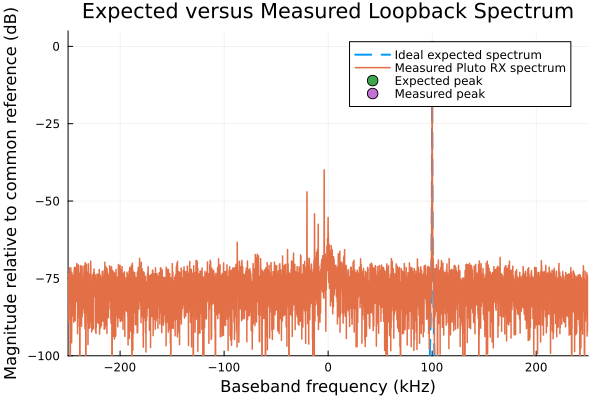

In [20]:
# ============================================================
# CELL 6: Overlay expected and measured spectra
# ============================================================

using FFTW
using Plots

# Number of received complex samples
N = length(rx_view)

# Sample indices
sample_index_rx = 0:(N - 1)

# Use the same Hann window for both signals
hann_window =
    0.5 .- 0.5 .* cos.(2π .* sample_index_rx ./ (N - 1))


# ------------------------------------------------------------
# Construct the ideal expected signal
# ------------------------------------------------------------

# Match the ideal signal amplitude to the average measured
# magnitude so the two spectra have a comparable scale.
expected_amplitude =
    sum(abs, rx_view) / N

expected_signal =
    expected_amplitude .* exp.(
        1im .* 2π .* expected_tone_frequency .*
        sample_index_rx ./ actual_sample_rate
    )


# ------------------------------------------------------------
# Apply the same window to both signals
# ------------------------------------------------------------

expected_windowed =
    expected_signal .* hann_window

measured_windowed =
    rx_view .* hann_window


# ------------------------------------------------------------
# Calculate both FFTs
# ------------------------------------------------------------

expected_spectrum =
    fftshift(fft(expected_windowed))

measured_spectrum =
    fftshift(fft(measured_windowed))

expected_magnitude =
    abs.(expected_spectrum)

measured_magnitude =
    abs.(measured_spectrum)


# ------------------------------------------------------------
# Use one common reference for both dB spectra
# ------------------------------------------------------------

common_reference =
    max(
        maximum(expected_magnitude),
        maximum(measured_magnitude)
    )

expected_spectrum_db =
    20 .* log10.(
        expected_magnitude ./ common_reference .+ eps()
    )

measured_spectrum_db =
    20 .* log10.(
        measured_magnitude ./ common_reference .+ eps()
    )


# ------------------------------------------------------------
# Construct the common frequency axis
# ------------------------------------------------------------

frequency_axis_khz =
    ((-N ÷ 2):(N ÷ 2 - 1)) .*
    (actual_sample_rate / N) ./ 1000


# ------------------------------------------------------------
# Locate the expected and measured FFT peaks
# ------------------------------------------------------------

expected_peak_index =
    argmax(expected_magnitude)

measured_peak_index =
    argmax(measured_magnitude)

expected_fft_peak_khz =
    frequency_axis_khz[expected_peak_index]

measured_fft_peak_khz =
    frequency_axis_khz[measured_peak_index]

frequency_error_hz =
    (measured_fft_peak_khz -
     expected_tone_frequency / 1000) * 1000

fft_bin_width_hz =
    actual_sample_rate / N


println("Requested tone frequency: ",
        expected_tone_frequency / 1000, " kHz")

println("Expected FFT peak:        ",
        expected_fft_peak_khz, " kHz")

println("Measured FFT peak:        ",
        measured_fft_peak_khz, " kHz")

println("Measured frequency error: ",
        frequency_error_hz, " Hz")

println("FFT bin width:            ",
        fft_bin_width_hz, " Hz")


# ------------------------------------------------------------
# Overlay both spectra on the same plot
# ------------------------------------------------------------

p = plot(
    frequency_axis_khz,
    expected_spectrum_db;
    xlabel = "Baseband frequency (kHz)",
    ylabel = "Magnitude relative to common reference (dB)",
    title = "Expected versus Measured Loopback Spectrum",
    label = "Ideal expected spectrum",
    linestyle = :dash,
    linewidth = 2,
    xlims = (-250, 250),
    ylims = (-100, 5),
    grid = true,
    legend = :topright
)

plot!(
    p,
    frequency_axis_khz,
    measured_spectrum_db;
    label = "Measured Pluto RX spectrum",
    linestyle = :solid,
    linewidth = 1.5
)

scatter!(
    p,
    [expected_fft_peak_khz],
    [expected_spectrum_db[expected_peak_index]];
    label = "Expected peak",
    markersize = 5
)

scatter!(
    p,
    [measured_fft_peak_khz],
    [measured_spectrum_db[measured_peak_index]];
    label = "Measured peak",
    markersize = 5
)

display(p)

In [21]:
# Disable the internal digital loopback
pysetattr(sdr, "loopback", 0)

# Stop the current cyclic TX buffer
try
    sdr.tx_destroy_buffer()
    println("Old TX buffer destroyed")
catch err
    println("TX cleanup warning: ", err)
end

# Remove the current RX buffer
try
    sdr.rx_destroy_buffer()
    println("Old RX buffer destroyed")
catch err
    println("RX cleanup warning: ", err)
end

println("Digital loopback disabled")
println("Pluto is ready for the physical RF-path test")

Old TX buffer destroyed
Old RX buffer destroyed
Digital loopback disabled
Pluto is ready for the physical RF-path test
